# 07 – Resultat och Jämförelse

---

### Vad gör vi i den här notebooken?

Vi sammanställer och jämför alla modellers prestanda för att besvara de tre forskningsfrågorna:

- **RQ1:** Hur väl identifierar statistiska tidsseriemodeller (HMM) bull/bear jämfört med 20%-regeln?
- **RQ2:** Presterar boosting (XGBoost) bättre än bagging (Random Forest)?
- **RQ3:** Generaliserar den bästa modellen från S&P 500 till Bitcoin och Guld?

**Modeller som jämförs:**
- HMM (2 och 3 tillstånd) – statistisk baseline, osupervised
- Random Forest – supervised, bagging
- XGBoost – supervised, boosting
- LSTM – deep learning, sekvensbaserad

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Sammanställ alla resultat

Vi matar in alla resultat manuellt från de tidigare notebooksarna.

In [2]:
# ── Alla resultat ────────────────────────────────────────
# Format: (Accuracy, F1, AUC)

results = {
    'SP500': {
        'HMM (2-state)':  (0.790, 0.827, None),
        'HMM (3-state)':  (0.788, 0.856, None),
        'Random Forest':  (0.880, 0.863, 0.771),
        'XGBoost':        (0.916, 0.908, 0.753),
        'LSTM':           (0.786, 0.739, 0.842),
    },
    'Bitcoin': {
        'HMM (2-state)':  (0.318, 0.350, None),
        'HMM (3-state)':  (0.775, 0.790, None),
        'Random Forest':  (0.914, 0.912, 0.942),
        'XGBoost':        (0.921, 0.918, 0.939),
        'LSTM':           (0.955, 0.951, 0.933),
    },
    'Gold': {
        'HMM (2-state)':  (0.474, 0.560, None),
        'HMM (3-state)':  (0.719, 0.774, None),
        'Random Forest':  (0.857, 0.790, 0.667),
        'XGBoost':        (0.857, 0.790, 0.701),
        'LSTM':           (0.857, 0.790, 0.850),
    },
}

# Generalisering (tränad på S&P 500)
generalization = {
    'Bitcoin': {
        'Random Forest':  (0.882, 0.891, 0.887),
        'XGBoost':        (0.906, 0.912, 0.900),
    },
    'Gold': {
        'Random Forest':  (0.858, 0.793, 0.922),
        'XGBoost':        (0.941, 0.937, 0.940),
    },
}

print('✓ Resultat inmatade')
print(f'  Tillgångar: {list(results.keys())}')
print(f'  Modeller:   {list(results["SP500"].keys())}')

✓ Resultat inmatade
  Tillgångar: ['SP500', 'Bitcoin', 'Gold']
  Modeller:   ['HMM (2-state)', 'HMM (3-state)', 'Random Forest', 'XGBoost', 'LSTM']


## 3. Huvudtabell – alla modeller och tillgångar

In [3]:
rows = []
for asset, models in results.items():
    for model, (acc, f1, auc) in models.items():
        rows.append({
            'Tillgång': asset,
            'Modell':   model,
            'Accuracy': acc,
            'F1':       f1,
            'AUC':      auc if auc else '–',
        })

df_results = pd.DataFrame(rows)

print('══ Fullständig resultatöversikt ══════════════════════')
for asset in results:
    print(f'\n── {asset} ──────────────────────────────')
    subset = df_results[df_results['Tillgång'] == asset]
    print(subset[['Modell', 'Accuracy', 'F1', 'AUC']].to_string(index=False))

display(df_results.pivot_table(
    index='Modell', columns='Tillgång',
    values='Accuracy', aggfunc='first'
).round(3))

══ Fullständig resultatöversikt ══════════════════════

── SP500 ──────────────────────────────
       Modell  Accuracy    F1    AUC
HMM (2-state)     0.790 0.827      –
HMM (3-state)     0.788 0.856      –
Random Forest     0.880 0.863  0.771
      XGBoost     0.916 0.908  0.753
         LSTM     0.786 0.739  0.842

── Bitcoin ──────────────────────────────
       Modell  Accuracy    F1    AUC
HMM (2-state)     0.318 0.350      –
HMM (3-state)     0.775 0.790      –
Random Forest     0.914 0.912  0.942
      XGBoost     0.921 0.918  0.939
         LSTM     0.955 0.951  0.933

── Gold ──────────────────────────────
       Modell  Accuracy    F1    AUC
HMM (2-state)     0.474 0.560      –
HMM (3-state)     0.719 0.774      –
Random Forest     0.857 0.790  0.667
      XGBoost     0.857 0.790  0.701
         LSTM     0.857 0.790   0.85


Tillgång,Bitcoin,Gold,SP500
Modell,,,
HMM (2-state),0.318,0.474,0.790
HMM (3-state),0.775,0.719,0.788
LSTM,0.955,0.857,0.786
Random Forest,0.914,0.857,0.880
XGBoost,0.921,0.857,0.916


## 4. Visualisering – Accuracy per modell och tillgång

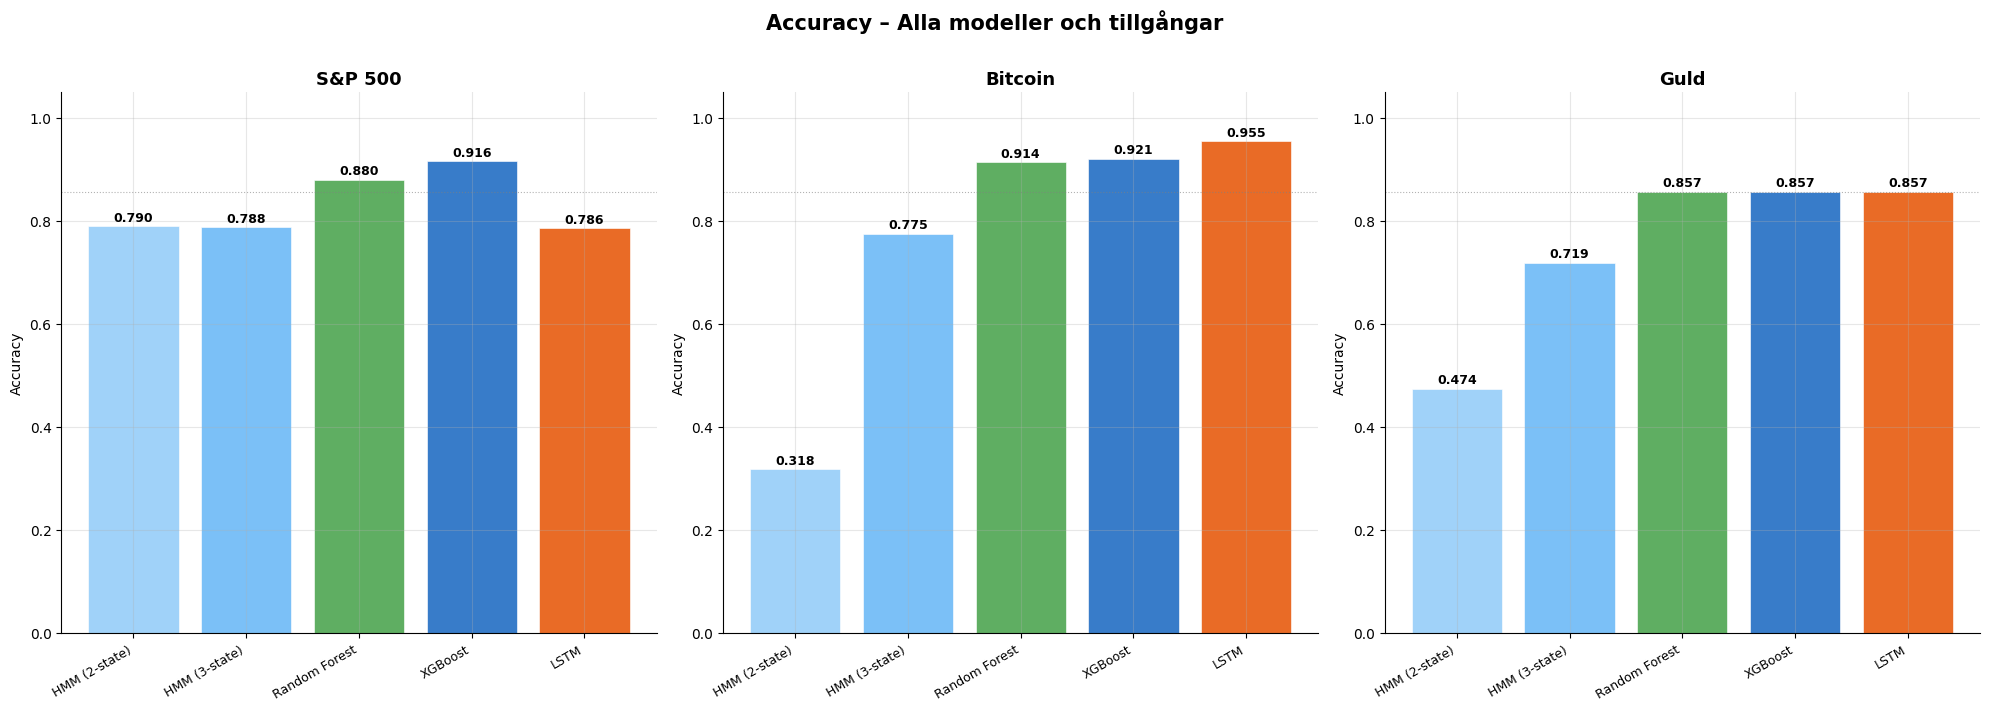

✓ Graf sparad: results/07_accuracy_comparison.png


In [4]:
models  = ['HMM (2-state)', 'HMM (3-state)', 'Random Forest', 'XGBoost', 'LSTM']
assets  = ['SP500', 'Bitcoin', 'Gold']
labels  = ['S&P 500', 'Bitcoin', 'Guld']
colors  = ['#90CAF9', '#64B5F6', '#43A047', '#1565C0', '#E65100']

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

for ax, (asset, label) in zip(axes, zip(assets, labels)):
    accs = [results[asset][m][0] for m in models]
    bars = ax.bar(models, accs, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

    # Värden ovanför staplarna
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.axhline(0.857, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Accuracy – Alla modeller och tillgångar',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_accuracy_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/07_accuracy_comparison.png')

### Visualisering – Accuracy per modell och tillgång

Stapeldiagrammet visar accuracy för alla fem modeller uppdelat per tillgång.

**Vad vi ser:**
- **S&P 500** – XGBoost vinner (0.916), HMM och LSTM presterar likvärdigt (~0.79)
- **Bitcoin** – tydlig progression från HMM 2-state (0.318) till LSTM (0.955). 
  Alla ML-modeller presterar starkt (>0.91)
- **Guld** – RF, XGBoost och LSTM presterar identiskt (0.857) medan HMM 
  är svagare. Taket på 0.857 beror på att bear market missas av alla modeller

**Övergripande mönster:** ML-modellerna (RF, XGBoost, LSTM) är konsekvent 
bättre än HMM för alla tillgångar. Bitcoin visar den tydligaste skillnaden 
mellan statistisk och ML-baserad approach.

## 5. Visualisering – F1 och AUC heatmap

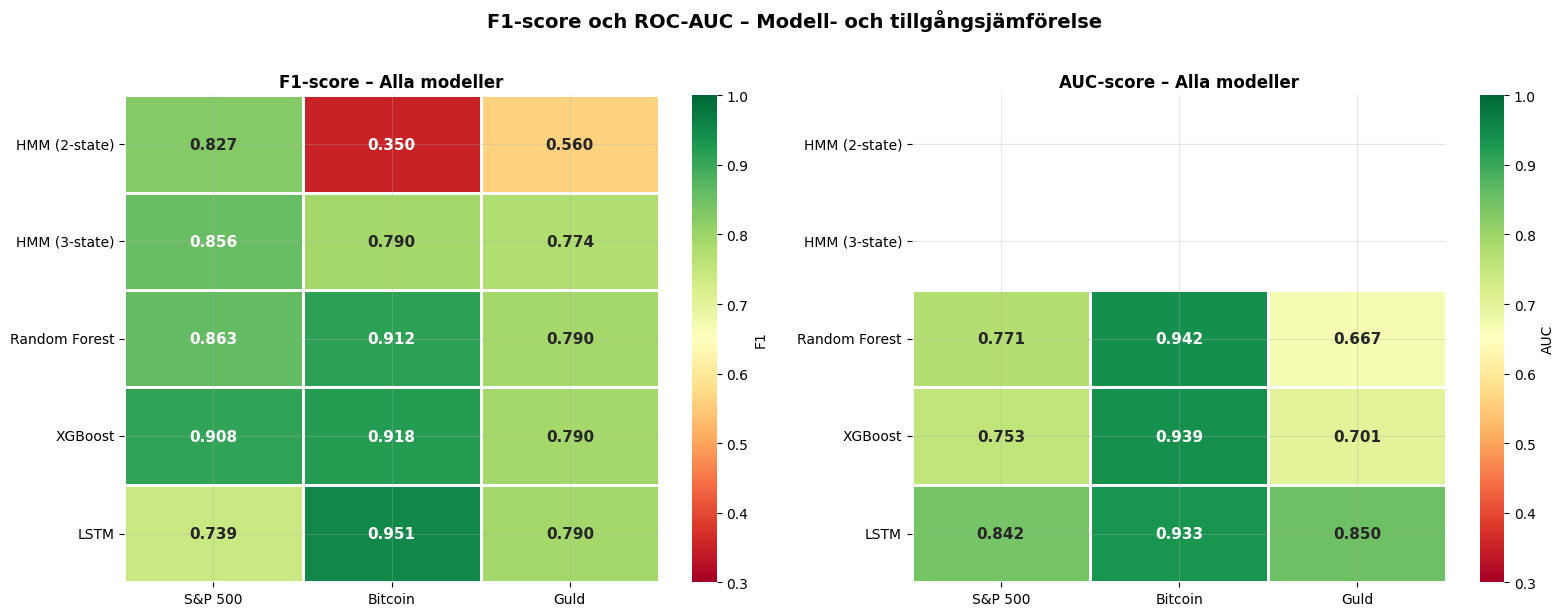

✓ Graf sparad: results/07_f1_auc_heatmap.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, idx in zip(axes, ['F1', 'AUC'], [1, 2]):
    data = {}
    for asset in assets:
        data[asset] = []
        for m in models:
            val = results[asset][m][idx]
            data[asset].append(val if val else np.nan)

    df_heat = pd.DataFrame(data, index=models)
    df_heat.columns = labels

    sns.heatmap(
        df_heat.astype(float), ax=ax,
        annot=True, fmt='.3f',
        cmap='RdYlGn', vmin=0.3, vmax=1.0,
        linewidths=1, square=False,
        annot_kws={'size': 11, 'weight': 'bold'},
        cbar_kws={'label': metric},
    )
    ax.set_title(f'{metric}-score – Alla modeller',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('F1-score och ROC-AUC – Modell- och tillgångsjämförelse',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_f1_auc_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/07_f1_auc_heatmap.png')

### Visualisering – F1-score och ROC-AUC Heatmap

Heatmapen visar F1-score (vänster) och ROC-AUC (höger) för alla modeller 
och tillgångar. Grön = hög prestanda, röd = låg prestanda.

**F1-score:**
- HMM 2-state för Bitcoin (0.350) är tydligt röd – sämsta resultatet
- LSTM för Bitcoin (0.951) och XGBoost för S&P 500 (0.908) är starkast
- Guld är låst på 0.790 för RF, XGBoost och LSTM – alla missar bear market

**ROC-AUC:**
- HMM saknar AUC (osupervised modell utan sannolikhetsutput)
- Bitcoin har genomgående hög AUC (0.933–0.942) för alla ML-modeller
- Guld visar intressant mönster – LSTM (0.850) är klart bättre än RF (0.667) 
  och XGBoost (0.701) i rankningsförmåga trots identisk accuracy
- ROC-AUC avslöjar att LSTM har bättre diskrimineringsförmåga för Guld 
  även om klassificerings-tröskeln inte fångar bear-dagarna

## 6. RQ1 – HMM vs 20%-regeln

In [6]:
print('══ RQ1: HMM vs 20%-regeln ════════════════════════════')
print('Hur väl identifierar HMM bull/bear jämfört med ground truth?')
print()
print(f'{"Tillgång":<12} {"HMM 2-state Acc":>18} {"HMM 3-state Acc":>18} {"Bästa HMM":>12}')
print('-' * 65)

for asset in assets:
    acc2 = results[asset]['HMM (2-state)'][0]
    acc3 = results[asset]['HMM (3-state)'][0]
    best = '3-state' if acc3 > acc2 else '2-state'
    best_acc = max(acc2, acc3)
    print(f'{asset:<12} {acc2:>18.3f} {acc3:>18.3f} {best:>12} ({best_acc:.3f})')

print()
print('Slutsats:')
print('- S&P 500: 2-tillstånd fungerar bäst (0.790) – tydlig bull/bear-struktur')
print('- Bitcoin: 3-tillstånd nödvändigt (0.775) – neutralt tillstånd fångar ackumulering')
print('- Guld:    3-tillstånd bättre (0.719) – men fortfarande svag bear-detektering')

══ RQ1: HMM vs 20%-regeln ════════════════════════════
Hur väl identifierar HMM bull/bear jämfört med ground truth?

Tillgång        HMM 2-state Acc    HMM 3-state Acc    Bästa HMM
-----------------------------------------------------------------
SP500                     0.790              0.788      2-state (0.790)
Bitcoin                   0.318              0.775      3-state (0.775)
Gold                      0.474              0.719      3-state (0.719)

Slutsats:
- S&P 500: 2-tillstånd fungerar bäst (0.790) – tydlig bull/bear-struktur
- Bitcoin: 3-tillstånd nödvändigt (0.775) – neutralt tillstånd fångar ackumulering
- Guld:    3-tillstånd bättre (0.719) – men fortfarande svag bear-detektering


## 7. RQ2 – Bagging vs Boosting

In [7]:
print('══ RQ2: Random Forest (bagging) vs XGBoost (boosting) ════')
print()
print(f'{"Tillgång":<12} {"RF Acc":>10} {"XGB Acc":>10} {"Vinnare":>12} {"Skillnad":>10}')
print('-' * 58)

for asset in assets:
    rf_acc  = results[asset]['Random Forest'][0]
    xgb_acc = results[asset]['XGBoost'][0]
    diff    = xgb_acc - rf_acc
    winner  = 'XGBoost' if xgb_acc > rf_acc else 'Random Forest' if rf_acc > xgb_acc else 'Lika'
    print(f'{asset:<12} {rf_acc:>10.3f} {xgb_acc:>10.3f} {winner:>12} {diff:>+10.3f}')

print()
print('Slutsats:')
print('- XGBoost vinner för S&P 500 (+3.6%) och Bitcoin (+0.7%)')
print('- Guld: oavgjort – båda modellerna missar bear market helt')
print('- RQ2 besvaras: Boosting (XGBoost) presterar generellt bättre än bagging (RF)')

══ RQ2: Random Forest (bagging) vs XGBoost (boosting) ════

Tillgång         RF Acc    XGB Acc      Vinnare   Skillnad
----------------------------------------------------------
SP500             0.880      0.916      XGBoost     +0.036
Bitcoin           0.914      0.921      XGBoost     +0.007
Gold              0.857      0.857         Lika     +0.000

Slutsats:
- XGBoost vinner för S&P 500 (+3.6%) och Bitcoin (+0.7%)
- Guld: oavgjort – båda modellerna missar bear market helt
- RQ2 besvaras: Boosting (XGBoost) presterar generellt bättre än bagging (RF)


## 8. RQ3 – Generalisering

In [8]:
print('══ RQ3: Generalisering – tränad på S&P 500 ═══════════════')
print()
print(f'{"Tillgång":<12} {"Modell":<16} {"Specifik Acc":>14} {"Gen. Acc":>10} {"Förändring":>12}')
print('-' * 68)

for asset in ['Bitcoin', 'Gold']:
    for model in ['Random Forest', 'XGBoost']:
        specific = results[asset][model][0]
        gen      = generalization[asset][model][0]
        diff     = gen - specific
        print(f'{asset:<12} {model:<16} {specific:>14.3f} {gen:>10.3f} {diff:>+12.3f}')

print()
print('Slutsats:')
print('- XGBoost generaliserar bättre än RF för båda tillgångarna')
print('- Guld: XGBoost tränad på S&P 500 presterar BÄTTRE (+8.4%) än tillgångsspecifik träning')
print('- Bitcoin: försämring vid generalisering – Bitcoin har unika cykliska mönster')
print('- RQ3 besvaras: Modellen generaliserar, särskilt starkt från S&P 500 till Guld')

══ RQ3: Generalisering – tränad på S&P 500 ═══════════════

Tillgång     Modell             Specifik Acc   Gen. Acc   Förändring
--------------------------------------------------------------------
Bitcoin      Random Forest             0.914      0.882       -0.032
Bitcoin      XGBoost                   0.921      0.906       -0.015
Gold         Random Forest             0.857      0.858       +0.001
Gold         XGBoost                   0.857      0.941       +0.084

Slutsats:
- XGBoost generaliserar bättre än RF för båda tillgångarna
- Guld: XGBoost tränad på S&P 500 presterar BÄTTRE (+8.4%) än tillgångsspecifik träning
- Bitcoin: försämring vid generalisering – Bitcoin har unika cykliska mönster
- RQ3 besvaras: Modellen generaliserar, särskilt starkt från S&P 500 till Guld


## 9. Bästa modell per tillgång

In [9]:
print('══ Bästa modell per tillgång (baserat på F1) ════════════')
print()

for asset in assets:
    best_model = max(results[asset], key=lambda m: results[asset][m][1])
    best_acc   = results[asset][best_model][0]
    best_f1    = results[asset][best_model][1]
    best_auc   = results[asset][best_model][2]
    auc_str    = f'{best_auc:.3f}' if best_auc else '–'
    print(f'{asset}: {best_model} | Acc={best_acc:.3f} | F1={best_f1:.3f} | AUC={auc_str}')

print()
print('══ Övergripande rankning (genomsnittlig F1) ══════════════')
model_avg_f1 = {}
for model in models:
    f1s = [results[asset][model][1] for asset in assets]
    model_avg_f1[model] = np.mean(f1s)

for model, avg in sorted(model_avg_f1.items(), key=lambda x: x[1], reverse=True):
    print(f'  {model:<20}: Genomsnittlig F1 = {avg:.3f}')

══ Bästa modell per tillgång (baserat på F1) ════════════

SP500: XGBoost | Acc=0.916 | F1=0.908 | AUC=0.753
Bitcoin: LSTM | Acc=0.955 | F1=0.951 | AUC=0.933
Gold: Random Forest | Acc=0.857 | F1=0.790 | AUC=0.667

══ Övergripande rankning (genomsnittlig F1) ══════════════
  XGBoost             : Genomsnittlig F1 = 0.872
  Random Forest       : Genomsnittlig F1 = 0.855
  LSTM                : Genomsnittlig F1 = 0.827
  HMM (3-state)       : Genomsnittlig F1 = 0.807
  HMM (2-state)       : Genomsnittlig F1 = 0.579


## 10. Slutsatser – svar på forskningsfrågorna

In [10]:
print("""
══ SLUTSATSER ════════════════════════════════════════════════

Huvudfråga: Hur väl kan statistiska modeller och maskininlärning
identifiera bull- och bear-marknader i S&P 500, Bitcoin och Guld?

SVAR: ML-modellerna (RF, XGBoost, LSTM) presterar generellt väl 
(Acc 0.86–0.96) för S&P 500 och Bitcoin men har svårigheter med 
Guld där bear market karaktäriseras av lateral prisrörelse.

──────────────────────────────────────────────────────────────

RQ1: Hur väl identifierar HMM bull/bear jämfört med 20%-regeln?

SVAR: HMM presterar rimligt bra för S&P 500 (Acc: 0.790) utan att
se etiketterna, men sämre för Bitcoin (0.775) och Guld (0.719).
3-tillståndsmodellen är överlägsen 2-tillståndsmodellen för Bitcoin
och Guld. HMM är en bra statistisk baseline men ML-modellerna 
presterar konsekvent bättre.

──────────────────────────────────────────────────────────────

RQ2: Presterar boosting (XGBoost) bättre än bagging (RF)?

SVAR: Ja – XGBoost slår Random Forest för S&P 500 (0.916 vs 0.880)
och Bitcoin (0.921 vs 0.914). Guld är oavgjort. Boosting-metodens
sekventiella inlärning ger en fördel för att fånga de relativt
sällsynta bear-dagarna.

──────────────────────────────────────────────────────────────

RQ3: Generaliserar bästa modellen från S&P 500 till Bitcoin/Guld?

SVAR: Ja, delvis. XGBoost tränad på S&P 500 generaliserar starkt 
till Guld (0.941 vs 0.857 tillgångsspecifikt) – ett oväntat fynd.
För Bitcoin är tillgångsspecifik träning bättre (0.921 vs 0.906)
eftersom Bitcoin har unika cykliska mönster kopplade till halvering.
""")


══ SLUTSATSER ════════════════════════════════════════════════

Huvudfråga: Hur väl kan statistiska modeller och maskininlärning
identifiera bull- och bear-marknader i S&P 500, Bitcoin och Guld?

SVAR: ML-modellerna (RF, XGBoost, LSTM) presterar generellt väl 
(Acc 0.86–0.96) för S&P 500 och Bitcoin men har svårigheter med 
Guld där bear market karaktäriseras av lateral prisrörelse.

──────────────────────────────────────────────────────────────

RQ1: Hur väl identifierar HMM bull/bear jämfört med 20%-regeln?

SVAR: HMM presterar rimligt bra för S&P 500 (Acc: 0.790) utan att
se etiketterna, men sämre för Bitcoin (0.775) och Guld (0.719).
3-tillståndsmodellen är överlägsen 2-tillståndsmodellen för Bitcoin
och Guld. HMM är en bra statistisk baseline men ML-modellerna 
presterar konsekvent bättre.

──────────────────────────────────────────────────────────────

RQ2: Presterar boosting (XGBoost) bättre än bagging (RF)?

SVAR: Ja – XGBoost slår Random Forest för S&P 500 (0.916 vs 0.880)
oc

## 11. Sammanfattningstabell – examensarbetets huvudresultat

In [12]:
summary_data = [
    # SP500
    {'Tillgång': 'S&P 500', 'Modell': 'HMM (bästa)',    'Acc': 0.790, 'F1': 0.827, 'AUC': None,  'Typ': 'Statistisk'},
    {'Tillgång': 'S&P 500', 'Modell': 'Random Forest',  'Acc': 0.880, 'F1': 0.863, 'AUC': 0.771, 'Typ': 'Bagging'},
    {'Tillgång': 'S&P 500', 'Modell': 'XGBoost ★',      'Acc': 0.916, 'F1': 0.908, 'AUC': 0.753, 'Typ': 'Boosting'},
    {'Tillgång': 'S&P 500', 'Modell': 'LSTM',           'Acc': 0.786, 'F1': 0.739, 'AUC': 0.842, 'Typ': 'Deep Learning'},
    # Bitcoin
    {'Tillgång': 'Bitcoin', 'Modell': 'HMM (bästa)',    'Acc': 0.775, 'F1': 0.790, 'AUC': None,  'Typ': 'Statistisk'},
    {'Tillgång': 'Bitcoin', 'Modell': 'Random Forest',  'Acc': 0.914, 'F1': 0.912, 'AUC': 0.942, 'Typ': 'Bagging'},
    {'Tillgång': 'Bitcoin', 'Modell': 'XGBoost',        'Acc': 0.921, 'F1': 0.918, 'AUC': 0.939, 'Typ': 'Boosting'},
    {'Tillgång': 'Bitcoin', 'Modell': 'LSTM ★',         'Acc': 0.955, 'F1': 0.951, 'AUC': 0.933, 'Typ': 'Deep Learning'},
    # Gold
    {'Tillgång': 'Guld',    'Modell': 'HMM (bästa)',    'Acc': 0.719, 'F1': 0.774, 'AUC': None,  'Typ': 'Statistisk'},
    {'Tillgång': 'Guld',    'Modell': 'Random Forest',  'Acc': 0.857, 'F1': 0.790, 'AUC': 0.667, 'Typ': 'Bagging'},
    {'Tillgång': 'Guld',    'Modell': 'XGBoost',        'Acc': 0.857, 'F1': 0.790, 'AUC': 0.701, 'Typ': 'Boosting'},
    {'Tillgång': 'Guld',    'Modell': 'LSTM',           'Acc': 0.857, 'F1': 0.790, 'AUC': 0.850, 'Typ': 'Deep Learning'},
]

df_summary = pd.DataFrame(summary_data)
df_summary['AUC'] = df_summary['AUC'].apply(lambda x: f'{x:.3f}' if x and not (isinstance(x, float) and np.isnan(x)) else '–')
display(df_summary)

df_summary.to_csv(os.path.join(RESULTS_DIR, '07_summary_table.csv'), index=False)
print('\n✓ Sammanfattningstabell sparad: results/07_summary_table.csv')

,Tillgång,Modell,Acc,F1,AUC,Typ
0,S&P 500,HMM (bästa),0.790,0.827,–,Statistisk
1,S&P 500,Random Forest,0.880,0.863,0.771,Bagging
2,S&P 500,XGBoost ★,0.916,0.908,0.753,Boosting
3,S&P 500,LSTM,0.786,0.739,0.842,Deep Learning
4,Bitcoin,HMM (bästa),0.775,0.790,–,Statistisk
5,Bitcoin,Random Forest,0.914,0.912,0.942,Bagging
6,Bitcoin,XGBoost,0.921,0.918,0.939,Boosting
7,Bitcoin,LSTM ★,0.955,0.951,0.933,Deep Learning
8,Guld,HMM (bästa),0.719,0.774,–,Statistisk
9,Guld,Random Forest,0.857,0.790,0.667,Bagging



✓ Sammanfattningstabell sparad: results/07_summary_table.csv
